# Movie Recommender System — Walkthrough

Individual Project · MovieLens 32M · Esade

This notebook demonstrates the full prototype: data loading, EDA, the train/test
protocol, every recommender, the evaluation comparison and qualitative examples.
All logic lives in the `src/` package; here we just orchestrate and visualize.

> Run from the project root (`MovieRecommender_Assignment/`).

In [1]:
import sys, os
# Make `import src` work whether the notebook is run from the project root
# or from the notebooks/ sub-folder.
ROOT = os.path.abspath('.')
if not os.path.isdir(os.path.join(ROOT, 'src')):
    ROOT = os.path.abspath('..')
os.chdir(ROOT); sys.path.insert(0, ROOT)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_loading import (load_ratings, load_items, describe_dataset,
                              filter_dataset, get_model_ratings,
                              train_test_split_ratings)
from src.baselines import (MostPopularRecommender, HighestAverageRatingRecommender,
                           BayesianAverageRecommender, RandomRecommender)
from src.content_based import ContentBasedRecommender
from src.collaborative_filtering import (ItemItemCollaborativeFiltering,
                                         UserUserCollaborativeFiltering)
from src.matrix_factorization import MatrixFactorizationRecommender
from src.evaluation import evaluate_model
pd.set_option('display.max_colwidth', 60)

## 1. Load the data

In [2]:
ratings = load_ratings()
items = load_items()
print(ratings.shape, items.shape)
ratings.head()

(32000204, 4) (87585, 3)


,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858


## 2. Exploratory data analysis
Computed on the **full** dataset.

In [3]:
stats = describe_dataset(ratings, items, return_dict=True)

DATASET SUMMARY
Users .............. 200,948
Items (rated) ...... 84,432
Items (catalog) .... 87,585
Interactions ....... 32,000,204
Sparsity ........... 99.8114%
Avg ratings/user ... 159.2
Avg ratings/item ... 379.0


Rating mean/median . 3.54 / 3.50

Rating distribution:
   0.5:  525,132  ( 1.6%)
   1.0:  946,675  ( 3.0%)
   1.5:  531,063  ( 1.7%)
   2.0: 2,028,622  ( 6.3%)
   2.5: 1,685,386  ( 5.3%)
   3.0: 6,054,990  (18.9%)
   3.5: 4,290,105  (13.4%)
   4.0: 8,367,654  (26.1%)
   4.5: 2,974,000  ( 9.3%)
   5.0: 4,596,577  (14.4%)

Top-10 most popular items:
         n_ratings                                                      title
movieId                                                                      
318         102929                           Shawshank Redemption, The (1994)
356         100296                                        Forrest Gump (1994)
296          98409                                        Pulp Fiction (1994)
2571         93808                                         Matrix, The (1999)
593          90330                           Silence of the Lambs, The (1991)
260          85010                  Star Wars: Episode IV - A New Hope (1977)
2959         77332        

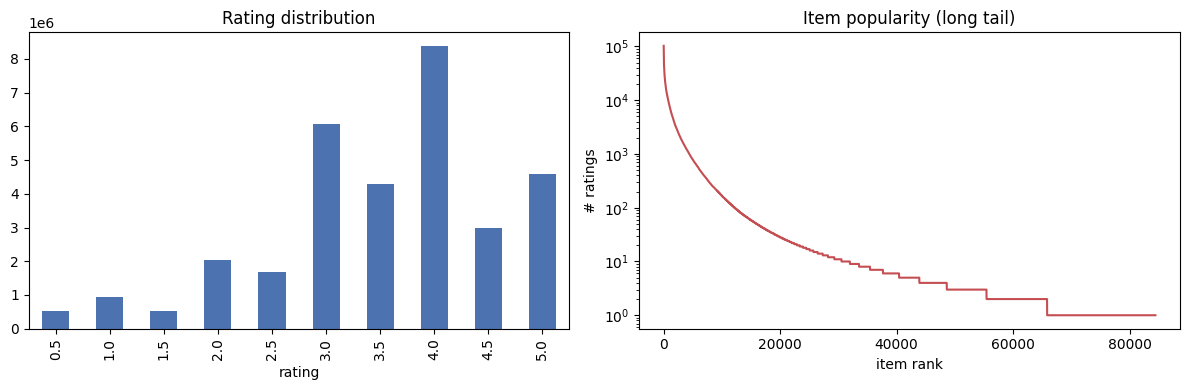

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ratings[config.RATING_COL].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4C72B0', title='Rating distribution')
ipc = ratings[config.ITEM_COL].value_counts().values
axes[1].plot(np.arange(1, len(ipc)+1), np.sort(ipc)[::-1], color='#C44E52')
axes[1].set_yscale('log'); axes[1].set_title('Item popularity (long tail)')
axes[1].set_xlabel('item rank'); axes[1].set_ylabel('# ratings')
plt.tight_layout(); plt.show()

## 3. Preprocessing & train/test split

We cap the catalog to the most-popular items, apply k-core filtering and
sub-sample users (see `config.MAX_USERS` / `MAX_ITEMS`) to keep the prototype
fast, then make a per-user 80/20 split so every test user is also present in
train. `get_model_ratings()` caches this filtered set to `data/processed/`.

In [5]:
model_ratings = get_model_ratings(use_cache=True)
train, test = train_test_split_ratings(model_ratings, test_size=0.2, strategy='random')
print('after filtering:', model_ratings.shape[0], 'ratings',
      '|', model_ratings[config.USER_COL].nunique(), 'users',
      '|', model_ratings[config.ITEM_COL].nunique(), 'items')
print('train:', len(train), ' test:', len(test))

after filtering: 1344249 ratings | 10000 users | 3000 items
train: 1075455  test: 268794


## 4. Train every model

In [6]:
item_pop = train[config.ITEM_COL].value_counts().to_dict()
n_total_users = train[config.USER_COL].nunique()
catalog_items = train[config.ITEM_COL].unique()

models = {
    'MostPopular': MostPopularRecommender().fit(train, items),
    'HighestAvg(min20)': HighestAverageRatingRecommender(min_ratings=20).fit(train, items),
    'BayesianAvg(IMDb)': BayesianAverageRecommender().fit(train, items),
    'Random': RandomRecommender().fit(train, items),
    'ContentBased(TF-IDF)': ContentBasedRecommender(use_tfidf=True).fit(train, items),
    'ContentBased(raw)': ContentBasedRecommender(use_tfidf=False).fit(train, items),
    'ItemItemCF(k=10)': ItemItemCollaborativeFiltering(k=10).fit(train),
    'UserUserCF(k=40)': UserUserCollaborativeFiltering(k=40).fit(train),
    'MatrixFactorization(SVD)': MatrixFactorizationRecommender(n_factors=20).fit(train),
}
list(models)

['MostPopular',
 'HighestAvg(min20)',
 'BayesianAvg(IMDb)',
 'Random',
 'ContentBased(TF-IDF)',
 'ContentBased(raw)',
 'ItemItemCF(k=10)',
 'UserUserCF(k=40)',
 'MatrixFactorization(SVD)']

## 5. Evaluate & compare
Same user sample and metric set for every model.

In [7]:
rng = np.random.RandomState(config.RANDOM_STATE)
test_users = test[config.USER_COL].unique()
eval_users = rng.choice(test_users, size=min(200, len(test_users)), replace=False)

rows = []
for name, m in models.items():
    res = evaluate_model(m, train, test, eval_users, k=config.TOP_K,
                         all_items=catalog_items, item_popularity=item_pop,
                         n_total_users=n_total_users)
    res['model'] = name; rows.append(res)

metrics = pd.DataFrame(rows).set_index('model')
metrics = metrics[['Precision@10','Recall@10','HitRate@10','NDCG@10','MRR','Coverage','Novelty']]
metrics.sort_values('NDCG@10', ascending=False).round(4)

,Precision@10,Recall@10,HitRate@10,NDCG@10,MRR,Coverage,Novelty
model,,,,,,,
MatrixFactorization(SVD),0.2515,0.2497,0.825,0.3412,0.5459,0.0930,2.3251
MostPopular,0.1235,0.1203,0.595,0.1696,0.3179,0.0140,1.6309
BayesianAvg(IMDb),0.0745,0.0853,0.480,0.1052,0.2178,0.0113,2.3332
ItemItemCF(k=10),0.0275,0.0398,0.235,0.0350,0.0664,0.3140,4.2377
HighestAvg(min20),0.0285,0.0405,0.240,0.0310,0.0460,0.0057,4.3698
UserUserCF(k=40),0.0085,0.0105,0.075,0.0092,0.0164,0.3773,5.0432
ContentBased(TF-IDF),0.0020,0.0030,0.020,0.0019,0.0028,0.0507,12.5683
ContentBased(raw),0.0010,0.0010,0.010,0.0007,0.0015,0.0497,12.5921
Random,0.0000,0.0000,0.000,0.0000,0.0000,0.0163,13.0878


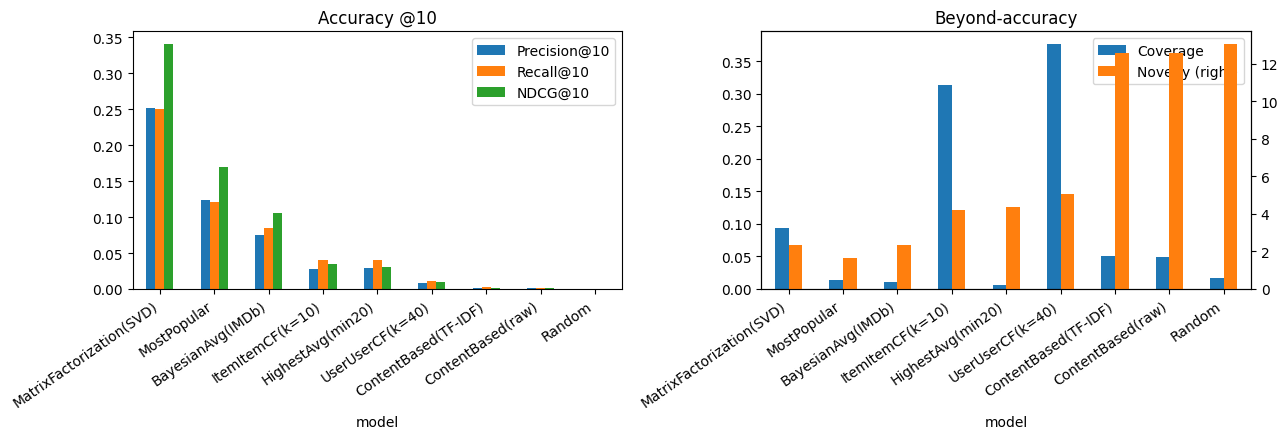

In [8]:
order = metrics.sort_values('NDCG@10', ascending=False).index
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
metrics.loc[order, ['Precision@10','Recall@10','NDCG@10']].plot(
    kind='bar', ax=ax[0], title='Accuracy @10')
ax[0].set_xticklabels(order, rotation=35, ha='right')
metrics.loc[order, ['Coverage','Novelty']].plot(
    kind='bar', ax=ax[1], secondary_y='Novelty', title='Beyond-accuracy')
ax[1].set_xticklabels(order, rotation=35, ha='right')
plt.tight_layout(); plt.show()

**Takeaway.** Matrix factorization (Truncated SVD) is the best overall model —
it beats popularity on accuracy *and* covers more of the catalog. Among the rest the
classic accuracy vs. discovery trade-off holds: popularity / Bayesian average are
accurate but narrow, while content-based and CF cover far more catalog and recommend
more novel items.

## 6. Qualitative example — recommendations by method

In [9]:
title_map = items.set_index(config.ITEM_COL)[config.TITLE_COL]
uid = eval_users[0]
print('User', uid)
for name, m in models.items():
    recs = m.recommend(uid, train, n=5, exclude_seen=True)
    print(f"{name:24s}: " + " | ".join(title_map.get(i, str(i)) for i in recs))

User 124204
MostPopular             : Silence of the Lambs, The (1991) | Star Wars: Episode IV - A New Hope (1977) | Jurassic Park (1993) | Lord of the Rings: The Fellowship of the Ring, The (2001) | Schindler's List (1993)
HighestAvg(min20)       : Planet Earth II (2016) | Band of Brothers (2001) | Planet Earth (2006) | Parasite (2019) | Double Indemnity (1944)
BayesianAvg(IMDb)       : Usual Suspects, The (1995) | Schindler's List (1993) | Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964) | Casablanca (1942) | 12 Angry Men (1957)
Random                  : Exit Wounds (2001) | Laws of Gravity (1992) | Reluctant Witness (2015) | They Were Expendable (1945) | Elections Day (2007)
ContentBased(TF-IDF)    : Little Soldier (Lille soldat) (2008) | Säg att du älskar mig (2006) | Wild Roots (2021) | Say You Will (2017) | No One Will Ever Know (2018)
ContentBased(raw)       : Asia (2020) | My Brother Tom (2001) | Gate of Flesh (Nikutai no mon) (1964) | Girls of the Ni

## 7. Conclusion

Matrix factorization (Truncated SVD, the course's method) is the strongest single
model, but there is no universal winner for every objective — CF and content-based
trade accuracy for much higher coverage and novelty. See
`Recommender_Systems_Project.pptx` for the full discussion, `results/metrics.csv`
for the ranking comparison, `results/rating_prediction.csv` for MAE/RMSE and
`results/tuning.csv` for the k / latent-factor sweep.